In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("./data/Food_Delivery_Times.csv")
data.head(10)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


In [3]:
data.shape

(1000, 9)

In [4]:
data.isna().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

For missing values,
-> experince is numerical value and we can assume, for missing values it will be close to mean or median
-> wheather, traffic-level or time of day we can assume will be the most probable class
-> although i think we can fill traffic level with  delivery time sensing correalation but it will be biased as its our target variable

In [5]:
data['Weather'] = data['Weather'].fillna(data['Weather'].mode()[0])
data['Traffic_Level'] = data['Traffic_Level'].fillna(data['Traffic_Level'].mode()[0])
data['Time_of_Day'] = data['Time_of_Day'].fillna(data['Time_of_Day'].mode()[0])

data['Courier_Experience_yrs'] = data['Courier_Experience_yrs'].fillna(data['Courier_Experience_yrs'].median())

In [6]:
data.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.592000,56.732000
std,288.819436,5.696656,7.204553,2.871198,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 1000 non-null   str    
 3   Traffic_Level           1000 non-null   str    
 4   Time_of_Day             1000 non-null   str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  1000 non-null   float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [8]:
data = data.drop(['Order_ID'], axis = 1)

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 1000 non-null   str    
 2   Traffic_Level           1000 non-null   str    
 3   Time_of_Day             1000 non-null   str    
 4   Vehicle_Type            1000 non-null   str    
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  1000 non-null   float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 62.6 KB


## Encoding & analyzing string (categorical) data

Your string columns: **Weather**, **Traffic_Level**, **Time_of_Day**, **Vehicle_Type**.

**Step 1 — Inspect categories** (see unique values and counts)  
**Step 2 — Encode** (convert to numbers for models: Label Encoding or One-Hot Encoding)  
**Step 3 — Analyze** (relationship with target, e.g. `Delivery_Time_min`)

In [ ]:

cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in cat_cols:
    print(f"--- {col} ---")
    print(data[col].value_counts())
    print()

--- Weather ---
Weather
Clear    500
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

--- Traffic_Level ---
Traffic_Level
Medium    420
Low       383
High      197
Name: count, dtype: int64

--- Time_of_Day ---
Time_of_Day
Morning      338
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

--- Vehicle_Type ---
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64



### Encoding options

| Method | When to use | Example |
|--------|-------------|--------|
| **Label Encoding** | Ordinal categories (e.g. Low < Medium < High) or tree-based models | Low→0, Medium→1, High→2 |
| **One-Hot Encoding** | Nominal categories (no order), linear models | Weather_Clear=0/1, Weather_Rainy=0/1, ... |

For **tree-based models** (Random Forest, XGBoost): Label Encoding is often enough.  
For **linear/regression models**: prefer One-Hot to avoid implying order.

In [11]:
# Label encoding for all 4 categorical columns
# We fit LabelEncoders, then save a simple dict mapping (JSON) so the app can reuse
# the same encoding without sklearn. Industry practice: persist the mapping, not the encoder.
from sklearn.preprocessing import LabelEncoder
import json
import os

cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
label_encoders = {}
encoding_map = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le
    # Build dict mapping: string label -> int (same as "simple map" for production)
    encoding_map[col] = {str(label): int(idx) for idx, label in enumerate(le.classes_)}


In [12]:
print(encoding_map)

{'Weather': {'Clear': 0, 'Foggy': 1, 'Rainy': 2, 'Snowy': 3, 'Windy': 4}, 'Traffic_Level': {'High': 0, 'Low': 1, 'Medium': 2}, 'Time_of_Day': {'Afternoon': 0, 'Evening': 1, 'Morning': 2, 'Night': 3}, 'Vehicle_Type': {'Bike': 0, 'Car': 1, 'Scooter': 2}}


In [13]:
# Save encodings for app reuse (app loads this JSON and uses .map() or dict.get())
project_root = os.getcwd() if os.path.isdir(os.path.join(os.getcwd(), "app")) else os.path.dirname(os.getcwd())
encodings_path = os.path.join(project_root, "app", "ml", "delivery_encodings.json")
os.makedirs(os.path.dirname(encodings_path), exist_ok=True)
with open(encodings_path, "w") as f:
    json.dump(encoding_map, f, indent=2)
print("Saved encodings to:", encodings_path)
data[cat_cols].head(10)

Saved encodings to: /Users/aryan/Desktop/Smart-food-delivery/app/ml/delivery_encodings.json


,Weather,Traffic_Level,Time_of_Day,Vehicle_Type
0,4,1,0,2
1,0,2,1,0
2,1,1,3,2
3,2,2,0,2
4,0,1,2,0
5,0,1,1,2
6,0,1,2,0
7,0,2,1,2
8,3,1,1,1
9,1,1,1,2


In [14]:
data

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,0,0,1,1,13,3.0,54
996,16.28,2,1,2,2,8,9.0,71
997,15.62,3,0,1,2,26,2.0,81
998,14.17,0,1,0,0,8,0.0,55


In [21]:
# train test split
from sklearn.model_selection import train_test_split

x = data.drop(["Delivery_Time_min"], axis=1)
y = data["Delivery_Time_min"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train size:", len(X_train), "| Test size:", len(X_test))

Train size: 800 | Test size: 200


In [24]:
# 1. Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("  MAE:", round(mean_absolute_error(y_test, y_pred_lr), 2))
print("  RMSE:", round(mean_squared_error(y_test, y_pred_lr), 2))

Linear Regression
  MAE: 7.29
  RMSE: 109.21


In [26]:
# 2. Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("  MAE:", round(mean_absolute_error(y_test, y_pred_rf), 2))
print("  RMSE:", round(mean_squared_error(y_test, y_pred_rf), 2))

Random Forest
  MAE: 7.06
  RMSE: 100.12


In [29]:
# 3. XGBoost (fallback: sklearn GradientBoosting if XGBoost/libomp missing on Mac)
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception as e:
    print("XGBoost not available:", e)
    print("On Mac, install OpenMP: brew install libomp")
    from sklearn.ensemble import GradientBoostingRegressor
    xgb = None
    XGB_AVAILABLE = False

if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
else:
    xgb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost" if XGB_AVAILABLE else "GradientBoosting (XGBoost fallback)")
print("  MAE:", round(mean_absolute_error(y_test, y_pred_xgb), 2))
print("  RMSE:", round(mean_squared_error(y_test, y_pred_xgb), 2))

XGBoost not available: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/aryan/Desktop/Smart-food-delivery/venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/aryan/Desktop/Smart-food-delivery/venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS

## Parameter tuning & results plots

For each model: **GridSearchCV** for hyperparameters, then **actual vs predicted** and **residual** plots.

Linear Regression (Ridge) — Best params: {'alpha': 0.01}
  MAE: 7.29
  RMSE: 109.21


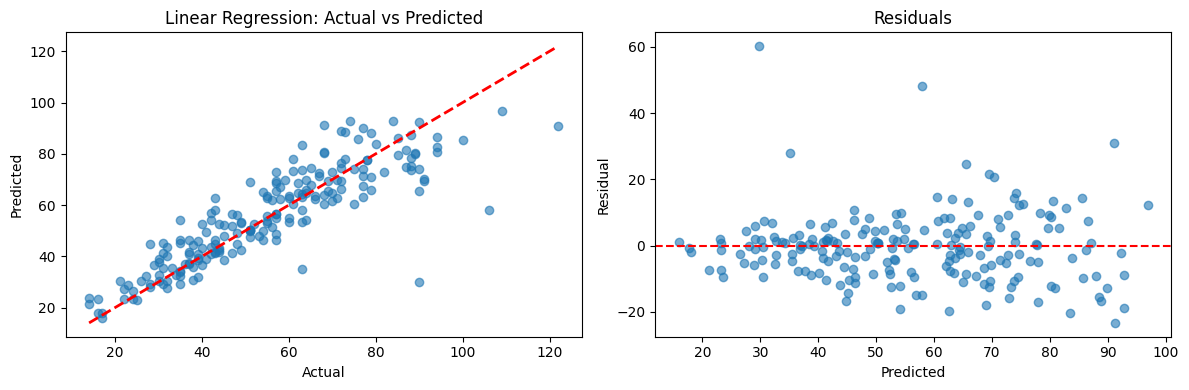

In [31]:
# 1. Linear Regression — parameter tuning (Ridge: tune alpha) + plots
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

lr_param_grid = {"alpha": [0.01, 0.1, 1.0, 10.0]}
lr_grid = GridSearchCV(Ridge(), lr_param_grid, cv=5, scoring="neg_mean_absolute_error")
lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_
y_pred_lr_tuned = lr_best.predict(X_test)

print("Linear Regression (Ridge) — Best params:", lr_grid.best_params_)
print("  MAE:", round(mean_absolute_error(y_test, y_pred_lr_tuned), 2))
print("  RMSE:", round(mean_squared_error(y_test, y_pred_lr_tuned), 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, y_pred_lr_tuned, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted"); axes[0].set_title("Linear Regression: Actual vs Predicted")
axes[1].scatter(y_pred_lr_tuned, y_test - y_pred_lr_tuned, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals")
plt.tight_layout(); plt.show()

Random Forest — Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
  MAE: 6.98
  RMSE: 98.28


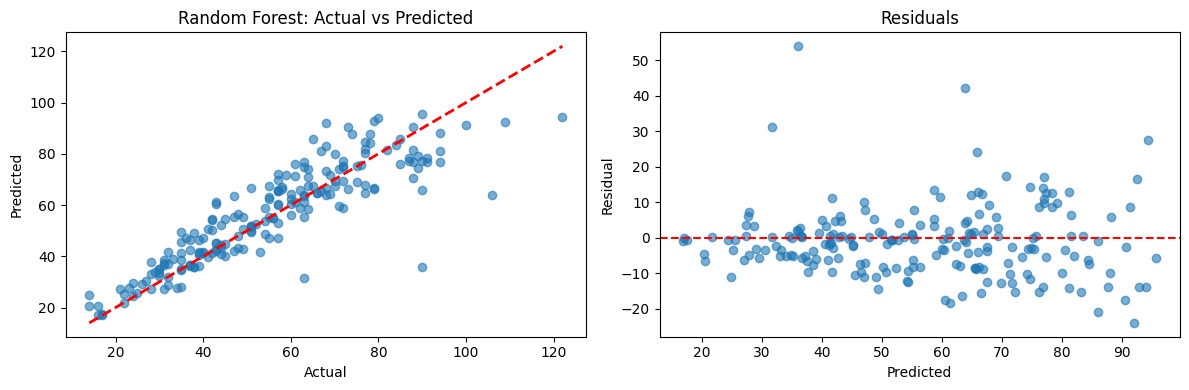

In [32]:
# 2. Random Forest — parameter tuning + plots
rf_param_grid = {"n_estimators": [50, 100, 150], "max_depth": [5, 10, 15, None], "min_samples_split": [2, 5]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
y_pred_rf_tuned = rf_best.predict(X_test)

print("Random Forest — Best params:", rf_grid.best_params_)
print("  MAE:", round(mean_absolute_error(y_test, y_pred_rf_tuned), 2))
print("  RMSE:", round(mean_squared_error(y_test, y_pred_rf_tuned), 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, y_pred_rf_tuned, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted"); axes[0].set_title("Random Forest: Actual vs Predicted")
axes[1].scatter(y_pred_rf_tuned, y_test - y_pred_rf_tuned, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals")
plt.tight_layout(); plt.show()

GradientBoosting — Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
  MAE: 6.57
  RMSE: 86.63


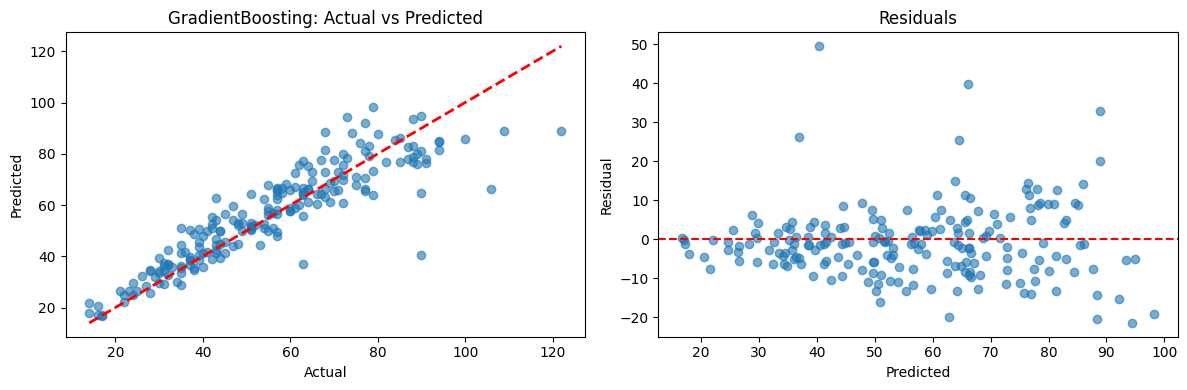

In [33]:
# 3. XGBoost — parameter tuning + plots (or GradientBoosting if XGBoost unavailable)
if XGB_AVAILABLE:
    xgb_param_grid = {"n_estimators": [50, 100, 150], "max_depth": [3, 5, 7], "learning_rate": [0.05, 0.1, 0.2]}
    xgb_grid = GridSearchCV(xgb.XGBRegressor(random_state=42), xgb_param_grid, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)
else:
    xgb_param_grid = {"n_estimators": [50, 100, 150], "max_depth": [3, 5, 7], "learning_rate": [0.05, 0.1, 0.2]}
    xgb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), xgb_param_grid, cv=3, scoring="neg_mean_absolute_error", n_jobs=-1)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
y_pred_xgb_tuned = xgb_best.predict(X_test)

print(("XGBoost" if XGB_AVAILABLE else "GradientBoosting") + " — Best params:", xgb_grid.best_params_)
print("  MAE:", round(mean_absolute_error(y_test, y_pred_xgb_tuned), 2))
print("  RMSE:", round(mean_squared_error(y_test, y_pred_xgb_tuned), 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, y_pred_xgb_tuned, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted"); axes[0].set_title(("XGBoost" if XGB_AVAILABLE else "GradientBoosting") + ": Actual vs Predicted")
axes[1].scatter(y_pred_xgb_tuned, y_test - y_pred_xgb_tuned, alpha=0.6)
axes[1].axhline(0, color="red", linestyle="--"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals")
plt.tight_layout(); plt.show()

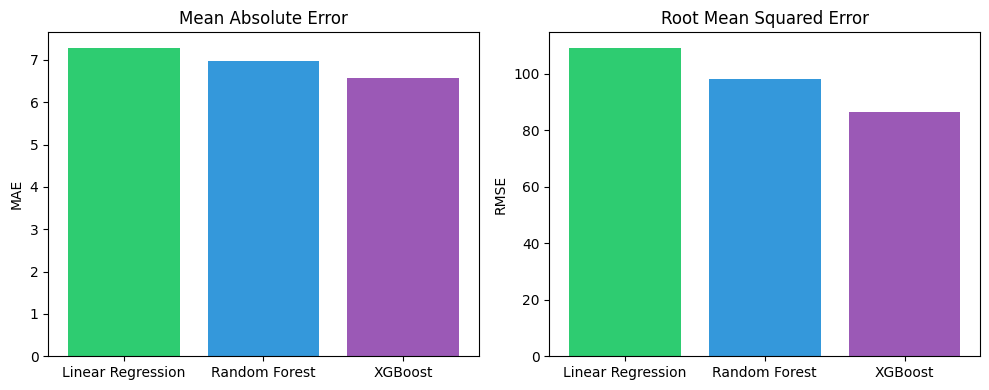

In [35]:
# Comparison: MAE & RMSE across tuned models
models = ["Linear Regression", "Random Forest", "XGBoost"]
mae_vals = [mean_absolute_error(y_test, y_pred_lr_tuned), mean_absolute_error(y_test, y_pred_rf_tuned), mean_absolute_error(y_test, y_pred_xgb_tuned)]
rmse_vals = [mean_squared_error(y_test, y_pred_lr_tuned), mean_squared_error(y_test, y_pred_rf_tuned), mean_squared_error(y_test, y_pred_xgb_tuned)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(models, mae_vals, color=["#2ecc71", "#3498db", "#9b59b6"]); axes[0].set_ylabel("MAE"); axes[0].set_title("Mean Absolute Error")
axes[1].bar(models, rmse_vals, color=["#2ecc71", "#3498db", "#9b59b6"]); axes[1].set_ylabel("RMSE"); axes[1].set_title("Root Mean Squared Error")
plt.tight_layout(); plt.show()

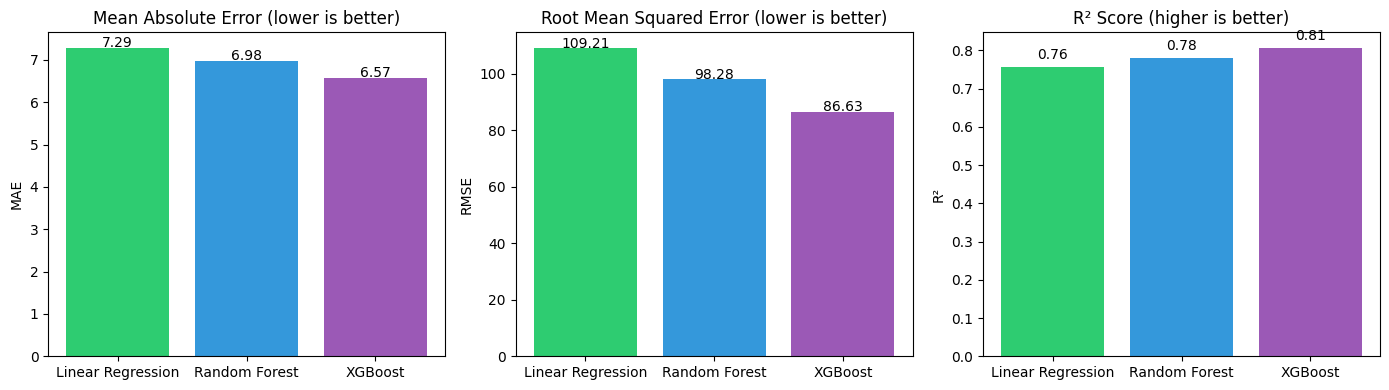

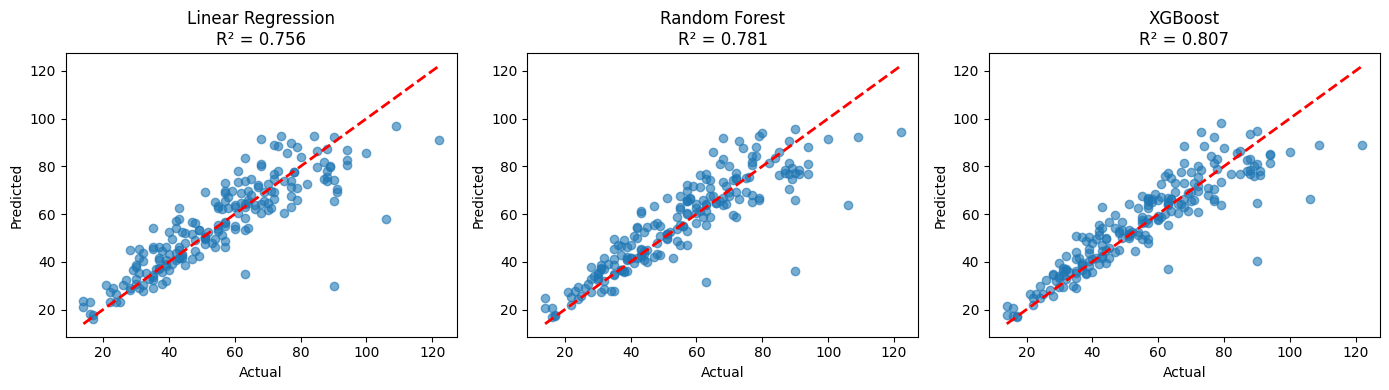

In [37]:
# Accuracy metrics & graphs (MAE, RMSE, R² + Actual vs Predicted)
from sklearn.metrics import r2_score

models = ["Linear Regression", "Random Forest", "XGBoost"]
preds = [y_pred_lr_tuned, y_pred_rf_tuned, y_pred_xgb_tuned]
mae_vals = [mean_absolute_error(y_test, p) for p in preds]
rmse_vals = [mean_squared_error(y_test, p) for p in preds]
r2_vals = [r2_score(y_test, p) for p in preds]

# Bar charts: MAE, RMSE, R² (higher R² = better fit)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#2ecc71", "#3498db", "#9b59b6"]
axes[0].bar(models, mae_vals, color=colors); axes[0].set_ylabel("MAE"); axes[0].set_title("Mean Absolute Error (lower is better)")
axes[1].bar(models, rmse_vals, color=colors); axes[1].set_ylabel("RMSE"); axes[1].set_title("Root Mean Squared Error (lower is better)")
axes[2].bar(models, r2_vals, color=colors); axes[2].set_ylabel("R²"); axes[2].set_title("R² Score (higher is better)")
for ax, vals in zip(axes, [mae_vals, rmse_vals, r2_vals]):
    for i, v in enumerate(vals):
        ax.text(i, v + (0.02 if v >= 0 else -0.05), round(v, 2), ha="center", fontsize=10)
plt.tight_layout(); plt.show()

# Actual vs Predicted for each model (accuracy visual)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, y_pred in zip(axes, models, preds):
    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
    r2 = r2_score(y_test, y_pred)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted"); ax.set_title(f"{name}\nR² = {r2:.3f}")
plt.tight_layout(); plt.show()

In [36]:
# Save the best (tuned) model for the app
import pickle
import os

project_root = os.getcwd() if os.path.isdir(os.path.join(os.getcwd(), "app")) else os.path.dirname(os.getcwd())
model_path = os.path.join(project_root, "app", "ml", "models", "delivery_model.pkl")
os.makedirs(os.path.dirname(model_path), exist_ok=True)
with open(model_path, "wb") as f:
    pickle.dump(xgb_best, f)
print("Saved model to:", model_path)

Saved model to: /Users/aryan/Desktop/Smart-food-delivery/app/ml/models/delivery_model.pkl
